# Cats vs Dogs Ensemble CNN (Bagging + Soft Voting)

This notebook consolidates the ensemble workflow into a single, reproducible pipeline:
- Train a bagged ensemble of CNNs on bootstrapped samples
- Evaluate per-model and ensemble performance
- Optimize ensemble weights and generate the same CSV/JSON/PNG outputs as the scripts

- **Dataset**: `training_set/` and `test_set/` with `cats/` and `dogs/` subfolders
- **Target encoding**: Cat = 0, Dog = 1 (alphabetical label inference)
- **Image size**: 64 x 64, rescaled to `[0, 1]`
- **Random seeds**: `numpy` and `tensorflow` both fixed to 42

## 1) Import Libraries and Configure Reproducibility

Set up all imports, constants, and output paths.

In [1]:
from pathlib import Path
import math
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

WORKDIR = Path('.')
TRAIN_DIR = WORKDIR / 'training_set'
TEST_DIR = WORKDIR / 'test_set'
MODELS_DIR = WORKDIR / 'ensemble_models'
ENSEMBLE_OUTPUT_DIR = WORKDIR / 'ensemble_output'

IMG_SIZE = (64, 64)
BATCH = 32
EPOCHS = 5
N_ESTIMATORS = 8
TRAIN_ENSEMBLE = True

CLASS_NAMES = ['Cat (0)', 'Dog (1)']

MODELS_DIR.mkdir(exist_ok=True)
ENSEMBLE_OUTPUT_DIR.mkdir(exist_ok=True)

print(f'TensorFlow version : {tf.__version__}')
print(f'Training directory : {TRAIN_DIR.resolve()}')
print(f'Test directory     : {TEST_DIR.resolve()}')
print(f'Models directory   : {MODELS_DIR.resolve()}')

2026-05-06 16:49:45.173579: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.16.2
Training directory : /Users/sebastianmachkovich/UW-Green Bay/CompSci_465/CNN-Image-Recognition/training_set
Test directory     : /Users/sebastianmachkovich/UW-Green Bay/CompSci_465/CNN-Image-Recognition/test_set
Models directory   : /Users/sebastianmachkovich/UW-Green Bay/CompSci_465/CNN-Image-Recognition/ensemble_models


## 2) Dataset Overview

Count images per class and visualize the class balance.

In [2]:
def count_images(path: Path) -> int:
    exts = {'.jpg', '.jpeg', '.png'}
    return sum(1 for p in path.glob('*') if p.suffix.lower() in exts)

train_cats = count_images(TRAIN_DIR / 'cats')
train_dogs = count_images(TRAIN_DIR / 'dogs')
test_cats = count_images(TEST_DIR / 'cats')
test_dogs = count_images(TEST_DIR / 'dogs')

print('Image counts')
print(f'  Training — Cats: {train_cats:>5},  Dogs: {train_dogs:>5},  Total: {train_cats + train_dogs:>5}')
print(f'  Test     — Cats: {test_cats:>5},  Dogs: {test_dogs:>5},  Total: {test_cats  + test_dogs:>5}')

Image counts
  Training — Cats:  4000,  Dogs:  4005,  Total:  8005
  Test     — Cats:  1011,  Dogs:  1012,  Total:  2023


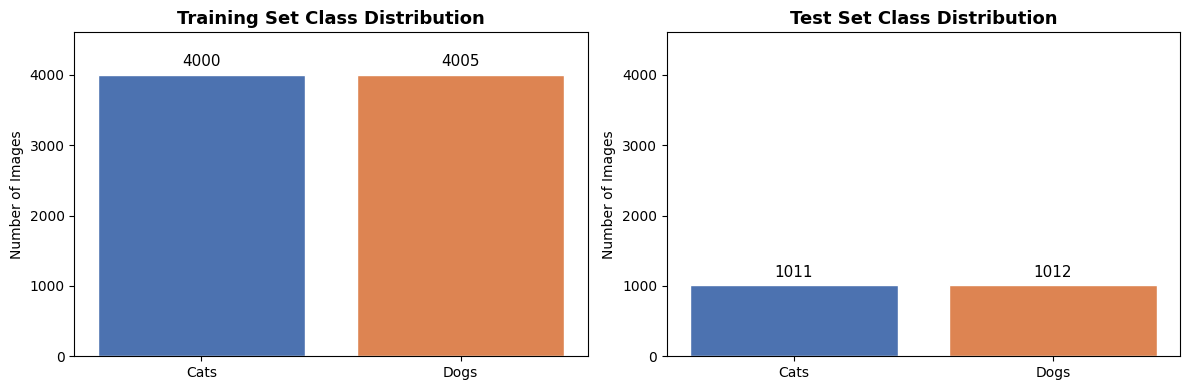

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split, cats, dogs in zip(
    axes,
    ['Training Set', 'Test Set'],
    [train_cats, test_cats],
    [train_dogs, test_dogs],
): 
    bars = ax.bar(['Cats', 'Dogs'], [cats, dogs], color=['#4C72B0', '#DD8452'], edgecolor='white')
    ax.bar_label(bars, fmt='%d', padding=4, fontsize=11)
    ax.set_title(f'{split} Class Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.set_ylim(0, max(train_cats, train_dogs) * 1.15)

plt.tight_layout()
plt.savefig('Ensemble Class Distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3) Data Preprocessing and Augmentation

Training data is augmented; the validation/test generator only rescales.

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=10,
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

val_gen = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=False,
)

print(f'Class indices: {val_gen.class_indices}')
print(f'Validation steps: {len(val_gen)}')

Found 2023 images belonging to 2 classes.
Class indices: {'cats': 0, 'dogs': 1}
Validation steps: 64


## 4) Model Architecture

A three-block CNN (32 → 64 → 128 filters) with Dropout is used for each estimator.

In [5]:
def build_model(input_shape=(64, 64, 3)):
    model = keras.Sequential(
        [
            keras.Input(shape=input_shape),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(1, activation='sigmoid'),
        ],
        name='cats_vs_dogs_cnn',
    )
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model((*IMG_SIZE, 3))
model.summary()

Model: "cats_vs_dogs_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

## 5) Bagging Ensemble Training

Set `TRAIN_ENSEMBLE = False` to skip training if models already exist in `ensemble_models/`.

In [6]:
def gather_image_paths(train_dir: Path) -> pd.DataFrame:
    classes = []
    paths = []
    for cname in sorted(train_dir.iterdir()):
        if not cname.is_dir():
            continue
        for fname in cname.iterdir():
            if fname.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                paths.append(str(fname.resolve()))
                classes.append(cname.name)
    return pd.DataFrame({'filename': paths, 'label': classes})

def train_bagging_ensemble() -> list[Path]:
    train_df = gather_image_paths(TRAIN_DIR)
    if train_df.empty:
        raise RuntimeError(f'No images found in {TRAIN_DIR}')

    saved_models: list[Path] = []
    for i in range(N_ESTIMATORS):
        print(f'\nTraining estimator {i + 1}/{N_ESTIMATORS}...')
        boot_df = train_df.sample(frac=1.0, replace=True, random_state=42 + i).reset_index(drop=True)

        train_gen = train_datagen.flow_from_dataframe(
            boot_df,
            x_col='filename',
            y_col='label',
            target_size=IMG_SIZE,
            batch_size=BATCH,
            class_mode='binary',
            shuffle=True,
        )

        model = build_model(input_shape=(*IMG_SIZE, 3))
        steps_per_epoch = math.ceil(len(boot_df) / BATCH)
        model.fit(
            train_gen,
            epochs=EPOCHS,
            steps_per_epoch=steps_per_epoch,
            validation_data=val_gen,
            verbose=1,
        )

        model_path = MODELS_DIR / f'model_{i + 1}.h5'
        model.save(model_path)
        saved_models.append(model_path)
        print(f'Saved estimator to {model_path}')

    return saved_models

if TRAIN_ENSEMBLE:
    saved_models = train_bagging_ensemble()
else:
    saved_models = sorted(MODELS_DIR.glob('*.h5'))
    print(f'Skipping training. Found {len(saved_models)} models.')


Training estimator 1/8...
Found 8005 validated image filenames belonging to 2 classes.
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 184ms/step - accuracy: 0.5698 - loss: 0.6782 - val_accuracy: 0.6278 - val_loss: 0.6443
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 205ms/step - accuracy: 0.6601 - loss: 0.6203 - val_accuracy: 0.6594 - val_loss: 0.6233
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 172ms/step - accuracy: 0.7094 - loss: 0.5686 - val_accuracy: 0.6930 - val_loss: 0.5992
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.7314 - loss: 0.5460 - val_accuracy: 0.7331 - val_loss: 0.5355
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - accuracy: 0.7477 - loss: 0.5127 - val_accuracy: 0.7108 - val_loss: 0.5592


Saved estimator to ensemble_models/model_1.h5

Training estimator 2/8...
Found 8005 validated image filenames belonging to 2 classes.
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 44s 169ms/step - accuracy: 0.5649 - loss: 0.6765 - val_accuracy: 0.6421 - val_loss: 0.6350
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 164ms/step - accuracy: 0.6658 - loss: 0.6113 - val_accuracy: 0.7227 - val_loss: 0.5628
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.7109 - loss: 0.5618 - val_accuracy: 0.7459 - val_loss: 0.5332
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.7403 - loss: 0.5218 - val_accuracy: 0.7657 - val_loss: 0.4991
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 191ms/step - accuracy: 0.7691 - loss: 0.4775 - val_accuracy: 0.7731 - val_loss: 0.4853


Saved estimator to ensemble_models/model_2.h5

Training estimator 3/8...
Found 8005 validated image filenames belonging to 2 classes.
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 153ms/step - accuracy: 0.5798 - loss: 0.6687 - val_accuracy: 0.6703 - val_loss: 0.6188
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 150ms/step - accuracy: 0.6790 - loss: 0.6001 - val_accuracy: 0.7064 - val_loss: 0.5640
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.7023 - loss: 0.5668 - val_accuracy: 0.6831 - val_loss: 0.5818
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 153ms/step - accuracy: 0.7468 - loss: 0.5201 - val_accuracy: 0.7484 - val_loss: 0.5007
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 44s 173ms/step - accuracy: 0.7666 - loss: 0.4800 - val_accuracy: 0.7548 - val_loss: 0.5097


Saved estimator to ensemble_models/model_3.h5

Training estimator 4/8...
Found 8005 validated image filenames belonging to 2 classes.
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 182ms/step - accuracy: 0.5512 - loss: 0.6820 - val_accuracy: 0.6248 - val_loss: 0.6519
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 179ms/step - accuracy: 0.6443 - loss: 0.6306 - val_accuracy: 0.6960 - val_loss: 0.5858
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 180ms/step - accuracy: 0.7111 - loss: 0.5631 - val_accuracy: 0.7014 - val_loss: 0.5805
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 44s 173ms/step - accuracy: 0.7333 - loss: 0.5297 - val_accuracy: 0.7543 - val_loss: 0.5077
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.7675 - loss: 0.4857 - val_accuracy: 0.7627 - val_loss: 0.4932


Saved estimator to ensemble_models/model_4.h5

Training estimator 5/8...
Found 8005 validated image filenames belonging to 2 classes.
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 47s 181ms/step - accuracy: 0.5673 - loss: 0.6728 - val_accuracy: 0.6649 - val_loss: 0.6069
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 172ms/step - accuracy: 0.6727 - loss: 0.6013 - val_accuracy: 0.7024 - val_loss: 0.5798
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 167ms/step - accuracy: 0.7098 - loss: 0.5587 - val_accuracy: 0.6797 - val_loss: 0.6116
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.7418 - loss: 0.5267 - val_accuracy: 0.7677 - val_loss: 0.4933
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 161ms/step - accuracy: 0.7645 - loss: 0.4886 - val_accuracy: 0.7736 - val_loss: 0.4862


Saved estimator to ensemble_models/model_5.h5

Training estimator 6/8...
Found 8005 validated image filenames belonging to 2 classes.
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 162ms/step - accuracy: 0.5696 - loss: 0.6753 - val_accuracy: 0.6856 - val_loss: 0.6116
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - accuracy: 0.6632 - loss: 0.6143 - val_accuracy: 0.7202 - val_loss: 0.5585
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 161ms/step - accuracy: 0.6879 - loss: 0.5833 - val_accuracy: 0.7355 - val_loss: 0.5503
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.7157 - loss: 0.5537 - val_accuracy: 0.7286 - val_loss: 0.5339
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 161ms/step - accuracy: 0.7388 - loss: 0.5266 - val_accuracy: 0.7435 - val_loss: 0.5064


Saved estimator to ensemble_models/model_6.h5

Training estimator 7/8...
Found 8005 validated image filenames belonging to 2 classes.
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 44s 170ms/step - accuracy: 0.5750 - loss: 0.6751 - val_accuracy: 0.5863 - val_loss: 0.6831
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.6731 - loss: 0.6055 - val_accuracy: 0.6673 - val_loss: 0.6173
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 157ms/step - accuracy: 0.7166 - loss: 0.5541 - val_accuracy: 0.7420 - val_loss: 0.5330
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - accuracy: 0.7488 - loss: 0.5118 - val_accuracy: 0.7519 - val_loss: 0.5160
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.7690 - loss: 0.4884 - val_accuracy: 0.7825 - val_loss: 0.4702


Saved estimator to ensemble_models/model_7.h5

Training estimator 8/8...
Found 8005 validated image filenames belonging to 2 classes.
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 172ms/step - accuracy: 0.5467 - loss: 0.6869 - val_accuracy: 0.6327 - val_loss: 0.6588
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 178ms/step - accuracy: 0.6316 - loss: 0.6382 - val_accuracy: 0.6456 - val_loss: 0.6166
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.6842 - loss: 0.5895 - val_accuracy: 0.7158 - val_loss: 0.5559
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - accuracy: 0.7126 - loss: 0.5615 - val_accuracy: 0.7123 - val_loss: 0.5622
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 150ms/step - accuracy: 0.7435 - loss: 0.5247 - val_accuracy: 0.7375 - val_loss: 0.5214


Saved estimator to ensemble_models/model_8.h5


## 6) Validation Snapshot (Average Ensemble on test_set)

Compute the average ensemble prediction on the validation generator and save `ensemble_preds.csv`.

In [7]:
def ensemble_validation_snapshot(model_paths: list[Path]) -> None:
    if not model_paths:
        print('No models available for validation snapshot.')
        return

    preds = []
    for mp in model_paths:
        model = keras.models.load_model(mp, compile=False)
        val_gen.reset()
        p = model.predict(val_gen, verbose=0).ravel()
        preds.append(p)

    avg_pred = np.mean(preds, axis=0)
    y_pred = (avg_pred >= 0.5).astype(int)
    y_true = val_gen.classes

    acc = np.mean(y_pred == y_true)
    print(f'Ensemble accuracy on validation set: {acc:.4f}')

    out_csv = ENSEMBLE_OUTPUT_DIR / 'ensemble_preds.csv'
    files = [Path(path).name for path in val_gen.filenames]
    df_out = pd.DataFrame({'file': files, 'y_true': y_true, 'y_prob': avg_pred, 'y_pred': y_pred})
    df_out.to_csv(out_csv, index=False)
    print(f'Saved ensemble predictions to {out_csv}')

ensemble_validation_snapshot(saved_models)

Ensemble accuracy on validation set: 0.7929
Saved ensemble predictions to ensemble_output/ensemble_preds.csv


## 7) Ensemble Evaluation Helpers

Load models, infer input sizes, and compute per-image probabilities.

In [8]:
def list_image_paths_and_labels(root_dir: Path):
    classes = sorted([d.name for d in root_dir.iterdir() if d.is_dir()])
    paths = []
    labels = []
    for idx, cls in enumerate(classes):
        cls_dir = root_dir / cls
        for fname in cls_dir.iterdir():
            if fname.name.startswith('.') or fname.name.startswith('_'):
                continue
            if fname.suffix.lower() not in ('.jpg', '.jpeg', '.png', '.bmp', '.gif'):
                continue
            paths.append(str(fname))
            labels.append(idx)
    return paths, np.array(labels), classes

def load_and_preprocess(path: str, target_size):
    img = Image.open(path).convert('RGB')
    img = img.resize((target_size[1], target_size[0]))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

def get_model_input_size(model):
    shape = getattr(model, 'input_shape', None)
    if shape is None and model.layers:
        shape = getattr(model.layers[0], 'input_shape', None)

    if not shape:
        return (IMG_SIZE[0], IMG_SIZE[1], 3)

    if len(shape) == 4:
        if shape[1] in (1, 3) and shape[2] and shape[3]:
            return (shape[2], shape[3], shape[1])
        if shape[1] and shape[2] and shape[3]:
            return (shape[1], shape[2], shape[3])

    if len(shape) == 3:
        return (shape[0], shape[1], shape[2])

    return (IMG_SIZE[0], IMG_SIZE[1], 3)

def predict_probs_for_model(model, paths, input_size):
    n = len(paths)
    probs = []
    for i in range(0, n, BATCH):
        batch_paths = paths[i:i + BATCH]
        batch = np.stack([load_and_preprocess(p, input_size) for p in batch_paths], axis=0)
        preds = model.predict(batch, verbose=0)
        preds = np.array(preds)
        if preds.ndim == 2 and preds.shape[1] == 2:
            p = preds[:, 1]
        elif preds.ndim == 2 and preds.shape[1] == 1:
            p = preds[:, 0]
        elif preds.ndim == 1:
            p = preds
        else:
            ex = np.exp(preds - np.max(preds, axis=1, keepdims=True))
            p = ex[:, 1] / np.sum(ex, axis=1)
        p = np.clip(p, 0.0, 1.0)
        probs.append(p)
    return np.concatenate(probs, axis=0)

## 8) Compute Per-Model Probabilities

In [9]:
paths, labels, classes = list_image_paths_and_labels(TEST_DIR)
if len(paths) == 0:
    raise RuntimeError('No images found in test_set. Check TEST_DIR path.')
print(f'Found {len(paths)} images across classes: {classes}')

model_files = sorted(MODELS_DIR.glob('*.h5'))
if not model_files:
    raise RuntimeError('No models found in ensemble_models/.')

all_probs = []
model_names = []
per_model_acc = []

for mf in model_files:
    print(f'Loading model {mf}...')
    model = keras.models.load_model(mf, compile=False)
    h, w, c = get_model_input_size(model)
    print(f'Model expects input approx {h}x{w}')
    probs = predict_probs_for_model(model, paths, (h, w, 3))
    preds = (probs >= 0.5).astype(int)
    acc = accuracy_score(labels, preds)
    print(f'Model {mf.name} accuracy: {acc:.4f}')
    all_probs.append(probs)
    model_names.append(mf.name)
    per_model_acc.append(acc)

all_probs = np.vstack(all_probs).T
print(f'Collected probabilities shape: {all_probs.shape}')

corr = np.corrcoef(all_probs.T)
print('Pairwise Pearson correlation matrix between model probabilities:')
print(corr)

bin_preds = (all_probs >= 0.5).astype(int)
disagreement = np.zeros((all_probs.shape[1], all_probs.shape[1]))
for i in range(all_probs.shape[1]):
    for j in range(all_probs.shape[1]):
        disagreement[i, j] = np.mean(bin_preds[:, i] != bin_preds[:, j])
print('Pairwise disagreement matrix (fraction where predictions differ):')
print(disagreement)

df_probs = pd.DataFrame(all_probs, columns=model_names)
df_probs['label'] = labels
df_probs.to_csv('ensemble_probs.csv', index=False)
print('Saved per-image probabilities to ensemble_probs.csv')

Found 2023 images across classes: ['cats', 'dogs']
Loading model ensemble_models/model_1.h5...
Model expects input approx 64x64
Model model_1.h5 accuracy: 0.7281
Loading model ensemble_models/model_2.h5...
Model expects input approx 64x64
Model model_2.h5 accuracy: 0.7593
Loading model ensemble_models/model_3.h5...
Model expects input approx 64x64
Model model_3.h5 accuracy: 0.7603
Loading model ensemble_models/model_4.h5...
Model expects input approx 64x64
Model model_4.h5 accuracy: 0.7553
Loading model ensemble_models/model_5.h5...
Model expects input approx 64x64
Model model_5.h5 accuracy: 0.7805
Loading model ensemble_models/model_6.h5...
Model expects input approx 64x64
Model model_6.h5 accuracy: 0.7548
Loading model ensemble_models/model_7.h5...
Model expects input approx 64x64
Model model_7.h5 accuracy: 0.7771
Loading model ensemble_models/model_8.h5...
Model expects input approx 64x64
Model model_8.h5 accuracy: 0.7425
Collected probabilities shape: (2023, 8)
Pairwise Pearson cor

## 9) Ensemble Methods and Weight Optimization

In [11]:
avg_probs = np.mean(all_probs, axis=1)
ensemble_preds = (avg_probs >= 0.5).astype(int)
ensemble_acc = accuracy_score(labels, ensemble_preds)
print(f"Equal-weight soft-voting ensemble accuracy: {ensemble_acc:.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    all_probs, labels, test_size=0.4, random_state=42, stratify=labels
)

meta = LogisticRegression(max_iter=1000)
meta.fit(X_train, y_train)
meta_preds = meta.predict(X_test)
meta_acc = accuracy_score(y_test, meta_preds)
print(f"Stacking (LogisticRegression) accuracy on split test: {meta_acc:.4f}")

def random_search_weights(X_val, y_val, n_iter=2000, seed=0):
    rng = np.random.RandomState(seed)
    best = {'acc': -1, 'w': None}
    m = X_val.shape[1]
    for _ in range(n_iter):
        w = rng.dirichlet(alpha=np.ones(m))
        wp = X_val.dot(w)
        preds = (wp >= 0.5).astype(int)
        acc = accuracy_score(y_val, preds)
        if acc > best['acc']:
            best['acc'] = acc
            best['w'] = w
    return best

print('Searching for best weighted-average on validation split (random search)...')
ws = random_search_weights(X_train, y_train, n_iter=2000, seed=123)
print(f"Best validation weighted-avg acc: {ws['acc']:.4f}")
print(f"Weights: {np.round(ws['w'], 4).tolist()}")

wp_test = X_test.dot(ws['w'])
wp_test_preds = (wp_test >= 0.5).astype(int)
wp_test_acc = accuracy_score(y_test, wp_test_preds)
print(f"Weighted-average ensemble accuracy on held-out split: {wp_test_acc:.4f}")

accs = np.array(per_model_acc)
prop_w = accs / accs.sum()
prop_wp = all_probs.dot(prop_w)
prop_preds = (prop_wp >= 0.5).astype(int)
prop_acc = accuracy_score(labels, prop_preds)
print(f"Proportional weights (by per-model acc) ensemble accuracy: {prop_acc:.4f}")

weights_out = {
    'model_names': model_names,
    'equal_weight_ensemble_acc': float(ensemble_acc),
    'stacking_acc': float(meta_acc),
    'best_val_weight_acc': float(ws['acc']),
    'best_val_weights': [float(x) for x in ws['w']],
    'best_test_weight_acc': float(wp_test_acc),
    'proportional_weights': [float(x) for x in prop_w],
    'proportional_weights_acc': float(prop_acc),
}
with open('ensemble_weights_summary.json', 'w') as f:
    json.dump(weights_out, f, indent=2)
print('Saved weights summary to ensemble_weights_summary.json')

print('Summary:')
for name, acc in zip(model_names, per_model_acc):
    print(f"- {name}: {acc:.4f}")
print(f"- Equal-weight ensemble: {ensemble_acc:.4f}")
print(f"- Stacking meta-learner: {meta_acc:.4f}")

Equal-weight soft-voting ensemble accuracy: 0.7894
Stacking (LogisticRegression) accuracy on split test: 0.7815
Searching for best weighted-average on validation split (random search)...
Best validation weighted-avg acc: 0.7980
Weights: [0.2458, 0.2154, 0.0929, 0.0063, 0.2797, 0.0063, 0.0647, 0.0889]
Weighted-average ensemble accuracy on held-out split: 0.7901
Proportional weights (by per-model acc) ensemble accuracy: 0.7889
Saved weights summary to ensemble_weights_summary.json
Summary:
- model_1.h5: 0.7281
- model_2.h5: 0.7593
- model_3.h5: 0.7603
- model_4.h5: 0.7553
- model_5.h5: 0.7805
- model_6.h5: 0.7548
- model_7.h5: 0.7771
- model_8.h5: 0.7425
- Equal-weight ensemble: 0.7894
- Stacking meta-learner: 0.7815


## 10) Best-Val Weighted Confusion Matrix

Recompute the confusion matrix and classification report on the validation split used for weight search.

Best validation weighted-avg acc (recomputed): 0.7980


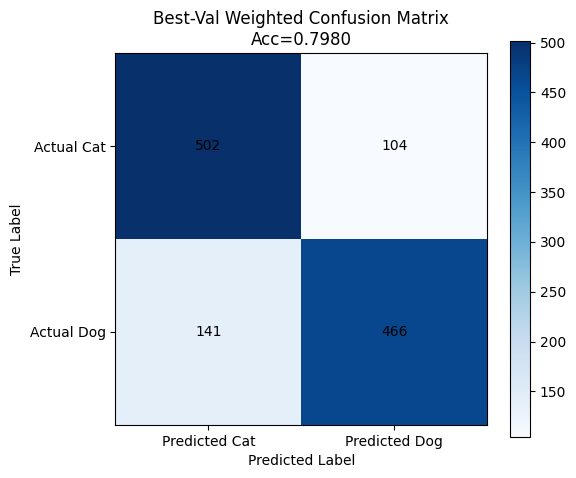

In [12]:
df = pd.read_csv('ensemble_probs.csv')
labels = df['label'].values
model_cols = [c for c in df.columns if c != 'label']
probs = df[model_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    probs, labels, test_size=0.4, random_state=42, stratify=labels
)

with open('ensemble_weights_summary.json') as f:
    weights_json = json.load(f)
weights = np.array(weights_json['best_val_weights'])

wp_val = X_train.dot(weights)
wp_val_preds = (wp_val >= 0.5).astype(int)
val_acc = accuracy_score(y_train, wp_val_preds)
print(f'Best validation weighted-avg acc (recomputed): {val_acc:.4f}')

cm = confusion_matrix(y_train, wp_val_preds)
report = classification_report(y_train, wp_val_preds, target_names=CLASS_NAMES, output_dict=True)

with open('best_val_weighted_classification_report.json', 'w') as f:
    json.dump(report, f, indent=2)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Cat', 'Predicted Dog'])
ax.set_yticklabels(['Actual Cat', 'Actual Dog'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
ax.set_title(f'Best-Val Weighted Confusion Matrix\nAcc={val_acc:.4f}')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('BestVal_Weighted_Confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 11) Ensemble Comparison Plots

Generate side-by-side confusion matrices and accuracy comparisons.

Computed accuracies:
  Equal-weight: 0.7894
  Weighted    : 0.7949


/var/folders/rs/x3zjpx8968g9d02qv_2w3fj00000gn/T/ipykernel_63172/1620752351.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


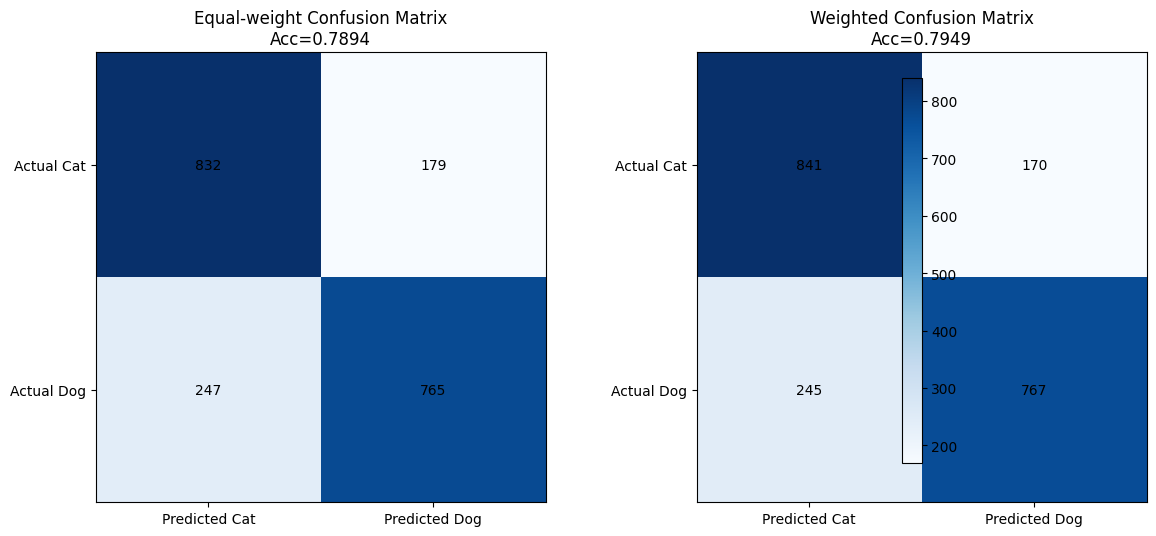

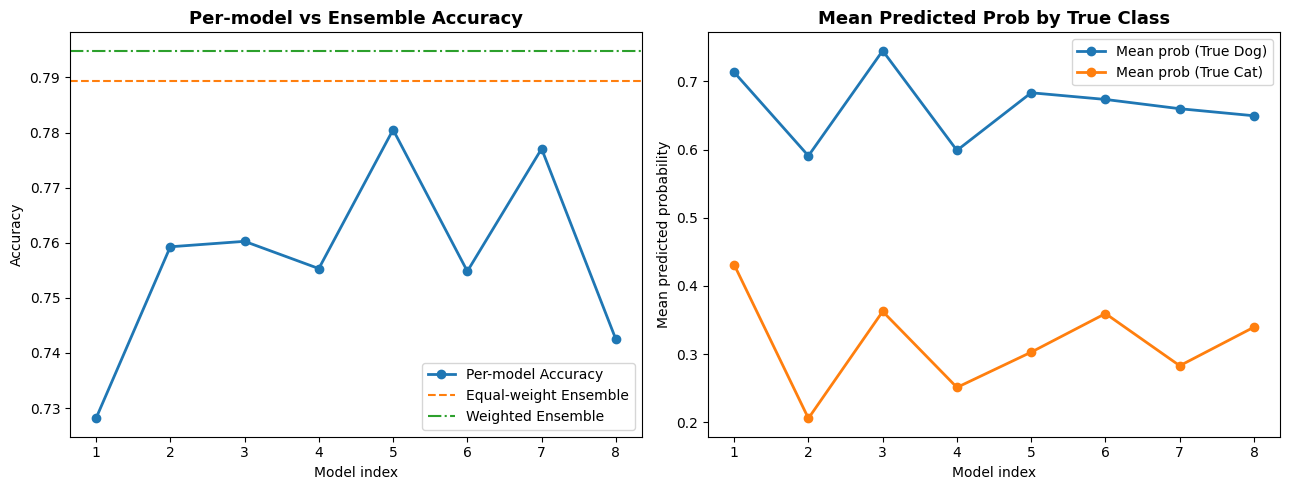

Saved weighted classification report


In [13]:
df = pd.read_csv('ensemble_probs.csv')
labels = df['label'].values
model_cols = [c for c in df.columns if c != 'label']
probs = df[model_cols].values

if Path('ensemble_weights_summary.json').exists():
    with open('ensemble_weights_summary.json') as f:
        weights_json = json.load(f)
    weights = np.array(weights_json.get('best_val_weights'))
else:
    weights = None

if weights is None:
    per_acc = [(probs[:, i] >= 0.5).astype(int) for i in range(probs.shape[1])]
    per_acc = [accuracy_score(labels, p) for p in per_acc]
    weights = np.array(per_acc)
    weights = weights / weights.sum()

avg_probs = np.mean(probs, axis=1)
avg_preds = (avg_probs >= 0.5).astype(int)
avg_acc = accuracy_score(labels, avg_preds)

weighted_probs = probs.dot(weights)
w_preds = (weighted_probs >= 0.5).astype(int)
w_acc = accuracy_score(labels, w_preds)

print('Computed accuracies:')
print(f'  Equal-weight: {avg_acc:.4f}')
print(f'  Weighted    : {w_acc:.4f}')

cm_eq = confusion_matrix(labels, avg_preds)
cm_w = confusion_matrix(labels, w_preds)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

def plot_confusion(cm, axis, title):
    im = axis.imshow(cm, cmap='Blues')
    axis.set_xticks([0, 1])
    axis.set_yticks([0, 1])
    axis.set_xticklabels(['Predicted Cat', 'Predicted Dog'])
    axis.set_yticklabels(['Actual Cat', 'Actual Dog'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axis.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
    axis.set_title(title)
    return im

im1 = plot_confusion(cm_eq, ax[0], f'Equal-weight Confusion Matrix\nAcc={avg_acc:.4f}')
im2 = plot_confusion(cm_w, ax[1], f'Weighted Confusion Matrix\nAcc={w_acc:.4f}')
fig.colorbar(im2, ax=ax.ravel().tolist())

plt.tight_layout()
plt.savefig('Ensemble_Confusion_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()

per_model_acc = [accuracy_score(labels, (probs[:, i] >= 0.5).astype(int)) for i in range(probs.shape[1])]
models_range = range(1, len(per_model_acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(models_range, per_model_acc, marker='o', label='Per-model Accuracy', linewidth=2)
ax1.axhline(avg_acc, color='C1', linestyle='--', label='Equal-weight Ensemble')
ax1.axhline(w_acc, color='C2', linestyle='-.', label='Weighted Ensemble')
ax1.set_title('Per-model vs Ensemble Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Model index')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(list(models_range))
ax1.legend()

mean_pos = [np.mean(probs[labels == 1, i]) for i in range(probs.shape[1])]
mean_neg = [np.mean(probs[labels == 0, i]) for i in range(probs.shape[1])]
ax2.plot(models_range, mean_pos, marker='o', label='Mean prob (True Dog)', linewidth=2)
ax2.plot(models_range, mean_neg, marker='o', label='Mean prob (True Cat)', linewidth=2)
ax2.set_title('Mean Predicted Prob by True Class', fontsize=13, fontweight='bold')
ax2.set_xlabel('Model index')
ax2.set_ylabel('Mean predicted probability')
ax2.set_xticks(list(models_range))
ax2.legend()

plt.tight_layout()
plt.savefig('Ensemble_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()

report_w = classification_report(labels, w_preds, target_names=CLASS_NAMES, output_dict=True)
with open('weighted_classification_report.json', 'w') as f:
    json.dump(report_w, f, indent=2)
print('Saved weighted classification report')

## 12) Conclusion

This notebook reproduces the ensemble CNN workflow end-to-end, including bagging, weight optimization, and the same reporting outputs used by the standalone scripts.

**Next ideas:**
- Increase image resolution (e.g., 128 x 128) to capture more detail
- Try transfer learning (e.g., MobileNetV2) for stronger baseline accuracy
- Add early stopping to reduce overfitting and training time